# Bachelorthesis — Mutual Fund Flows
## Replication of Table 1: Sample Summary Statistics
**Base paper:** Barber, Huang, Odean & Schwarz (2022), *Attention-Induced Trading and Returns: Evidence from Robinhood Users*, Review of Financial Studies, v35 n4.

This notebook replicates **Table 1** (Sample Summary Statistics) using CRSP data from the `real, clear data/raw/` directory.

**Data sources:**
- `monthly_returns_2000_2025.csv` — monthly TNA, returns, NAV per share class
- `fund_summary_quarterly_2000_2025.csv` — quarterly fund characteristics (fees, objective, index flag)
- `fund_portfolio_map_2000_2025.csv` — maps share classes (`crsp_fundno`) to portfolios (`crsp_portno`)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 130

from pathlib import Path

BASE_DIR      = Path('.')
DATA_DIR      = BASE_DIR / 'real, clear data' / 'raw'
PROCESSED_DIR = BASE_DIR / 'processed'
OUTPUT_DIR    = BASE_DIR / 'output'
PROCESSED_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

FILE_RETURNS = DATA_DIR / 'monthly_returns_2000_2025.csv'
FILE_SUMMARY = DATA_DIR / 'fund_summary_quarterly_2000_2025.csv'
FILE_PORTMAP = DATA_DIR / 'fund_portfolio_map_2000_2025.csv'

print('Data directory:', DATA_DIR.resolve())
for f in [FILE_RETURNS, FILE_SUMMARY, FILE_PORTMAP]:
    print(f'  {f.name}: exists={f.exists()}')

Data directory: /Users/justin.hahn/Downloads/Uni /Bachlorarbeit /code/Bachelorarbeit/real data/real, clear data/raw
  monthly_returns_2000_2025.csv: exists=True
  fund_summary_quarterly_2000_2025.csv: exists=True
  fund_portfolio_map_2000_2025.csv: exists=True


In [2]:
# ── Load raw data ────────────────────────────────────────────────────────────
print('Loading monthly returns...')
ret = pd.read_csv(FILE_RETURNS, low_memory=False, parse_dates=['caldt'])
ret['mtna'] = pd.to_numeric(ret['mtna'], errors='coerce')
ret['mret'] = pd.to_numeric(ret['mret'], errors='coerce')
ret['mnav'] = pd.to_numeric(ret['mnav'], errors='coerce')

print('Loading fund summary...')
fs = pd.read_csv(FILE_SUMMARY, low_memory=False,
                 parse_dates=['caldt', 'first_offer_dt'])

print('Loading portfolio map...')
pm = pd.read_csv(FILE_PORTMAP, low_memory=False,
                 parse_dates=['begdt', 'enddt'])

print(f'\nReturns : {ret.shape[0]:>10,} rows | {ret["crsp_fundno"].nunique():>6,} funds | {ret["caldt"].min().date()} – {ret["caldt"].max().date()}')
print(f'Summary : {fs.shape[0]:>10,} rows | {fs["crsp_fundno"].nunique():>6,} funds')
print(f'Port map: {pm.shape[0]:>10,} rows | {pm["crsp_portno"].nunique():>6,} portfolios')

Loading monthly returns...
Loading fund summary...
Loading portfolio map...

Returns :  8,690,724 rows | 70,750 funds | 2000-01-31 – 2025-12-31
Summary :  2,801,929 rows | 70,559 funds
Port map:     81,068 rows | 30,362 portfolios


In [3]:
# ── Fund classification ──────────────────────────────────────────────────────
# Use the annual snapshot (summary_period2 == 'AQ') for stable characteristics.
# Equity funds: lipper_asset_cd == 'EQ'
# Active funds: index_fund_flag is NaN AND et_flag is NaN
# Index funds : index_fund_flag is not NaN AND et_flag is NaN  (exclude ETFs)

fs_aq = fs[fs['summary_period2'] == 'AQ'].copy()

# Keep one row per fund (most recent snapshot) for classification
fs_latest = (fs_aq.sort_values('caldt')
                  .groupby('crsp_fundno')
                  .last()
                  .reset_index())

equity_mask = fs_latest['lipper_asset_cd'] == 'EQ'
active_mask = equity_mask & fs_latest['index_fund_flag'].isna() & fs_latest['et_flag'].isna()
index_mask  = equity_mask & fs_latest['index_fund_flag'].notna() & fs_latest['et_flag'].isna()

active_funds = set(fs_latest.loc[active_mask, 'crsp_fundno'])
index_funds  = set(fs_latest.loc[index_mask,  'crsp_fundno'])

print(f'Active equity funds : {len(active_funds):,}')
print(f'Index  equity funds : {len(index_funds):,}')

Active equity funds : 40,599
Index  equity funds : 3,268


In [4]:
# ── Aggregate share classes → portfolios ─────────────────────────────────────
# The paper works at portfolio level (crsp_portno), not share-class level.
# For each month: TNA-weighted return, sum of TNA across share classes.

# Build a fund → portfolio lookup valid at each date
# (use the most recent mapping before or at the observation date)
pm_sorted = pm.sort_values(['crsp_portno', 'begdt'])

# Simple approach: use the latest mapping per crsp_fundno
fund_to_port = (pm.sort_values('begdt')
                  .groupby('crsp_fundno')['crsp_portno']
                  .last()
                  .reset_index())

ret2 = ret.merge(fund_to_port, on='crsp_fundno', how='left')

# For funds not in the portfolio map, use crsp_fundno as its own portfolio
ret2['crsp_portno'] = ret2['crsp_portno'].fillna(ret2['crsp_fundno'])

# Aggregate to portfolio-month: TNA-weighted return, total TNA
def tna_wtd_ret(g):
    w = g['mtna'].fillna(0)
    r = g['mret']
    total = w.sum()
    if total > 0:
        return (r * w).sum() / total
    return r.mean()

print('Aggregating to portfolio level (this takes ~1 min)...')
port_ret = (ret2.groupby(['crsp_portno', 'caldt'])
                .apply(lambda g: pd.Series({
                    'mtna': g['mtna'].sum(min_count=1),
                    'mret': tna_wtd_ret(g),
                    'n_classes': len(g)
                }))
                .reset_index())

print(f'Portfolio-months: {len(port_ret):,} | Portfolios: {port_ret["crsp_portno"].nunique():,}')

Aggregating to portfolio level (this takes ~1 min)...
Portfolio-months: 3,664,032 | Portfolios: 33,451


In [5]:
# ── Map portfolios to fund type (active / index) ─────────────────────────────
# A portfolio is active if the majority of its share classes are active funds.

# For each crsp_portno, find all crsp_fundno in the map
port_funds = pm[['crsp_portno', 'crsp_fundno']].drop_duplicates()

port_funds['is_active'] = port_funds['crsp_fundno'].isin(active_funds)
port_funds['is_index']  = port_funds['crsp_fundno'].isin(index_funds)

port_type = (port_funds.groupby('crsp_portno')
                       .agg(n_active=('is_active','sum'),
                            n_index =('is_index', 'sum'),
                            n_total =('crsp_fundno','count'))
                       .reset_index())

port_type['fund_type'] = np.where(port_type['n_active'] > 0, 'active',
                         np.where(port_type['n_index']  > 0, 'index', 'other'))

active_ports = set(port_type.loc[port_type['fund_type']=='active','crsp_portno'])
index_ports  = set(port_type.loc[port_type['fund_type']=='index', 'crsp_portno'])

print(f'Active portfolios: {len(active_ports):,}')
print(f'Index  portfolios: {len(index_ports):,}')

# Tag the portfolio-month data
port_ret['fund_type'] = np.where(port_ret['crsp_portno'].isin(active_ports), 'active',
                        np.where(port_ret['crsp_portno'].isin(index_ports),  'index', 'other'))

active_pm = port_ret[port_ret['fund_type'] == 'active'].copy()
index_pm  = port_ret[port_ret['fund_type'] == 'index'].copy()

print(f'\nActive portfolio-months: {len(active_pm):,}')
print(f'Index  portfolio-months: {len(index_pm):,}')

Active portfolios: 15,657
Index  portfolios: 1,626

Active portfolio-months: 1,755,078
Index  portfolio-months: 217,756


In [7]:
# ── Fund age and flow ────────────────────────────────────────────────────────
# Age = months since first observation in the returns data (proxy for inception)
# Flow (%) = (TNA_t - TNA_{t-1} * (1 + R_t)) / TNA_{t-1}  * 100

def add_age_flow(df):
    df = df.sort_values(['crsp_portno', 'caldt']).copy()

    # Age: months since first appearance
    # np.timedelta64(1,'M') is ambiguous in newer pandas/numpy — use days instead
    first_date = df.groupby('crsp_portno')['caldt'].transform('min')
    df['age_months'] = ((df['caldt'] - first_date).dt.days / 30.4375).round()
    df['age_years']  = df['age_months'] / 12

    # Lagged TNA
    df['tna_lag'] = df.groupby('crsp_portno')['mtna'].shift(1)

    # Flow (%)
    df['flow_pct'] = np.where(
        df['tna_lag'].notna() & (df['tna_lag'] > 0),
        (df['mtna'] - df['tna_lag'] * (1 + df['mret'])) / df['tna_lag'] * 100,
        np.nan
    )
    # Flow ($Mn)
    df['flow_mn'] = np.where(
        df['tna_lag'].notna() & (df['tna_lag'] > 0),
        df['mtna'] - df['tna_lag'] * (1 + df['mret']),
        np.nan
    )
    return df

active_pm = add_age_flow(active_pm)
index_pm  = add_age_flow(index_pm)

print('Age and flow computed.')
print(f'Active: {len(active_pm):,} rows | Index: {len(index_pm):,} rows')

Age and flow computed.
Active: 1,755,078 rows | Index: 217,756 rows


In [8]:
# ── Market-adjusted return ───────────────────────────────────────────────────
# Market-adj ret = fund return - value-weighted market return (from FF factors)
# We use the Fama-French Mkt-RF + RF as the market return proxy.

FF_PATH = Path('..') / 'data' / 'F-F_Research_Data_Factors_daily.csv'

ff = pd.read_csv(FF_PATH, skiprows=4, header=0, low_memory=False)
ff.columns = ff.columns.str.strip()
ff = ff.rename(columns={'Unnamed: 0': 'date'})
ff['date'] = pd.to_datetime(ff['date'].astype(str).str.strip(),
                             format='%Y%m%d', errors='coerce')
ff = ff.dropna(subset=['date'])
for c in ['Mkt-RF', 'RF']:
    ff[c] = pd.to_numeric(ff[c], errors='coerce') / 100

# Compound daily → monthly market return
ff['ym'] = ff['date'].dt.to_period('M')
mkt_monthly = (ff.groupby('ym')
                 .apply(lambda g: pd.Series({
                     'mkt_ret': (1 + g['Mkt-RF'] + g['RF']).prod() - 1,
                     'rf':      (1 + g['RF']).prod() - 1
                 }))
                 .reset_index())
mkt_monthly['caldt'] = mkt_monthly['ym'].dt.to_timestamp('M') + pd.offsets.MonthEnd(0)

def add_mkt_adj(df):
    df = df.merge(mkt_monthly[['caldt','mkt_ret','rf']], on='caldt', how='left')
    df['ret_mktadj'] = df['mret'] - df['mkt_ret']
    df['ret_excess']  = df['mret'] - df['rf']
    return df

active_pm = add_mkt_adj(active_pm)
index_pm  = add_mkt_adj(index_pm)

print('Market-adjusted returns computed.')
print(f'FF data: {ff["date"].min().date()} – {ff["date"].max().date()}')

Market-adjusted returns computed.
FF data: 1926-07-01 – 2026-03-31


In [9]:
# ── Summary statistics (replicating Table 1 layout) ─────────────────────────
# Columns: No. obs | Mean | CS std | TS std | P5 | P25 | P50 | P75 | P95
#
# CS std = cross-sectional std: compute std across funds each month, then average
# TS std = time-series std: compute monthly mean across funds, then std over time

def cs_std(df, col):
    """Average of monthly cross-sectional standard deviations."""
    return df.groupby('caldt')[col].std().mean()

def ts_std(df, col):
    """Std of monthly cross-sectional means."""
    return df.groupby('caldt')[col].mean().std()

def summary_row(df, col, label, scale=1):
    """One row of Table 1 for variable *col* in dataframe *df*."""
    s = df[col].dropna() * scale
    n = len(s)
    if n == 0:
        return {' ': label, 'No. obs': 0}
    cs = cs_std(df.assign(**{col: df[col] * scale}), col)
    ts = ts_std(df.assign(**{col: df[col] * scale}), col)
    return {
        ' ':        label,
        'No. obs':  f'{n:,}',
        'Mean':     f'{s.mean():.2f}',
        'CS std':   f'{cs:.2f}',
        'TS std':   f'{ts:.2f}',
        'P5':       f'{s.quantile(0.05):.2f}',
        'P25':      f'{s.quantile(0.25):.2f}',
        'P50':      f'{s.quantile(0.50):.2f}',
        'P75':      f'{s.quantile(0.75):.2f}',
        'P95':      f'{s.quantile(0.95):.2f}',
    }

def build_table(df, label):
    rows = []
    rows.append(summary_row(df, 'mtna',       'Size ($Mn)'))
    rows.append(summary_row(df, 'age_years',  'Age (years)'))
    rows.append(summary_row(df, 'flow_pct',   'Flow (%)'))
    rows.append(summary_row(df, 'flow_mn',    'Flow ($Mn)'))
    rows.append(summary_row(df, 'mret',       'Unadjusted ret (%)', scale=100))
    rows.append(summary_row(df, 'ret_mktadj', 'Market-adj. ret (%)', scale=100))
    tbl = pd.DataFrame(rows).set_index(' ')
    tbl.index.name = label
    return tbl

print('Building summary tables...')
tbl_active = build_table(active_pm, f'Active funds (N = {active_pm["crsp_portno"].nunique():,})')
tbl_index  = build_table(index_pm,  f'Index funds (N = {index_pm["crsp_portno"].nunique():,})')

print('Done.')
print(tbl_active)
print()
print(tbl_index)

Building summary tables...
Done.
                             No. obs     Mean   CS std  TS std      P5    P25  \
Active funds (N = 12,086)                                                       
Size ($Mn)                 1,722,982  1336.54  5567.96  508.07    3.70  43.30   
Age (years)                1,755,078     8.93     4.39    4.58    0.58   3.25   
Flow (%)                   1,705,291   147.58  7846.25  865.50   -5.47  -1.35   
Flow ($Mn)                 1,705,291    -2.12   176.17   10.15  -44.17  -4.03   
Unadjusted ret (%)         1,750,697     1.42    64.07   12.03   -7.59  -1.59   
Market-adj. ret (%)        1,257,452     0.86    87.04   13.68   -4.85  -1.70   

                              P50     P75      P95  
Active funds (N = 12,086)                           
Size ($Mn)                 195.50  762.20  5063.59  
Age (years)                  7.42   13.58    22.33  
Flow (%)                    -0.32    1.25    10.78  
Flow ($Mn)                  -0.20    1.36    35.40  


ValueError: 'transform' is not allowed as a keyword argument; axhline generates its own transform.

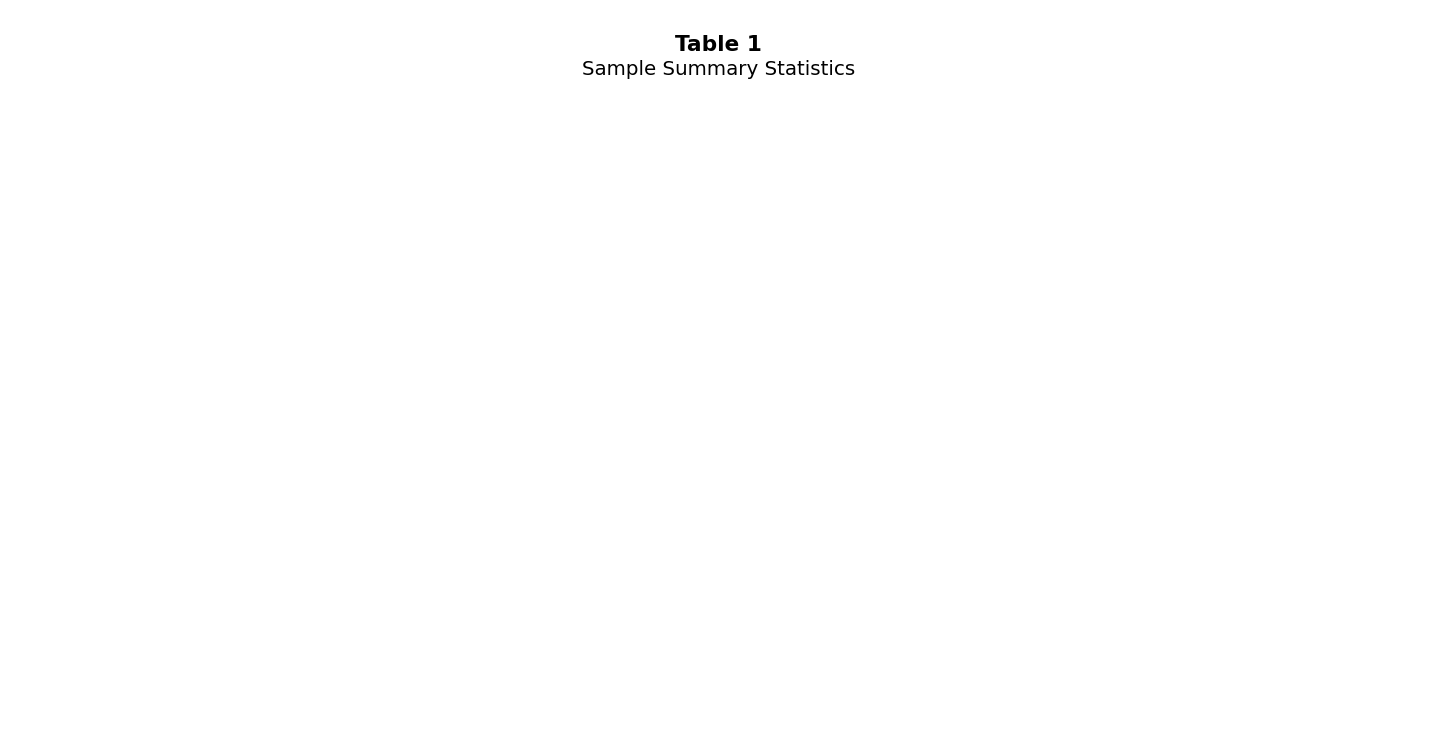

In [10]:
# ── Render publication-style Table 1 ─────────────────────────────────────────

def render_table1(tbl_active, tbl_index):
    cols = ['No. obs', 'Mean', 'CS std', 'TS std', 'P5', 'P25', 'P50', 'P75', 'P95']

    # Collect all rows: section header + data rows for each group
    sections = [
        (tbl_active.index.name, tbl_active),
        (tbl_index.index.name,  tbl_index),
    ]

    # Count total rows: 2 section headers + rows per section + 1 blank between
    n_data = sum(len(t) for _, t in sections)
    n_total = n_data + len(sections) + 1   # +1 blank separator

    fig_h = 0.38 * n_total + 1.6
    fig, ax = plt.subplots(figsize=(14, fig_h))
    ax.set_axis_off()

    # ── Layout ────────────────────────────────────────────────────────────
    TOP   = 0.97
    FS_T  = 12      # title
    FS_H  = 9.5     # column headers
    FS_B  = 9       # body
    FS_N  = 7.5     # notes
    RH    = 0.048   # row height (fraction of axes)
    LX    = 0.01    # left edge for row labels
    # x positions for the 9 value columns
    CX = [0.28, 0.37, 0.46, 0.55, 0.63, 0.70, 0.77, 0.84, 0.91]

    # ── Title ─────────────────────────────────────────────────────────────
    ax.text(0.5, TOP, 'Table 1', ha='center', va='top',
            fontsize=FS_T, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, TOP - 0.035, 'Sample Summary Statistics',
            ha='center', va='top', fontsize=FS_T - 1, transform=ax.transAxes)

    # Top rule
    y_rule_top = TOP - 0.075
    ax.axhline(y_rule_top, color='black', lw=1.2, xmin=0.01, xmax=0.99,
               transform=ax.transAxes)

    # ── Column headers ─────────────────────────────────────────────────────
    y_head = y_rule_top - RH * 0.7
    for cx, col in zip(CX, cols):
        ax.text(cx, y_head, col, ha='center', va='center',
                fontsize=FS_H, transform=ax.transAxes)

    # Rule under headers
    y_rule_head = y_head - RH * 0.6
    ax.axhline(y_rule_head, color='black', lw=0.8, xmin=0.01, xmax=0.99,
               transform=ax.transAxes)

    # ── Data rows ──────────────────────────────────────────────────────────
    y_cur = y_rule_head - RH * 0.3

    for sec_label, tbl in sections:
        # Section header (bold)
        ax.text(LX, y_cur, sec_label, ha='left', va='center',
                fontsize=FS_B, fontweight='bold', transform=ax.transAxes)
        y_cur -= RH

        for row_label, row in tbl.iterrows():
            ax.text(LX + 0.01, y_cur, row_label, ha='left', va='center',
                    fontsize=FS_B, transform=ax.transAxes)
            for cx, col in zip(CX, cols):
                val = row.get(col, '')
                ax.text(cx, y_cur, str(val), ha='center', va='center',
                        fontsize=FS_B, transform=ax.transAxes)
            y_cur -= RH

        y_cur -= RH * 0.4   # blank line between sections

    # Bottom rule
    y_rule_bot = y_cur + RH * 0.2
    ax.axhline(y_rule_bot, color='black', lw=1.0, xmin=0.01, xmax=0.99,
               transform=ax.transAxes)

    # ── Notes ──────────────────────────────────────────────────────────────
    notes = (
        'This table presents summary statistics for the active mutual funds sample and '
        'for the passive index funds sample. Data: CRSP 2000–2025. '
        'CS std = cross-sectional standard deviation (computed each month, averaged over time). '
        'TS std = time-series standard deviation of monthly cross-sectional means. '
        'Flow (%) = (TNA_t − TNA_{t−1}·(1+R_t)) / TNA_{t−1} × 100. '
        'Market-adj. ret = fund return minus value-weighted market return (FF Mkt factor).'
    )
    ax.text(0.01, y_rule_bot - 0.015, notes, ha='left', va='top',
            fontsize=FS_N, wrap=True, transform=ax.transAxes,
            style='italic', color='#333333')

    plt.tight_layout()
    out_path = OUTPUT_DIR / 'table1_summary_statistics.png'
    plt.savefig(out_path, dpi=180, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved → {out_path}')

render_table1(tbl_active, tbl_index)